<a href="https://colab.research.google.com/github/mannatkalani/leafscan/blob/main/CNN_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_dir = "New Plant Diseases Dataset(Augmented)/train"
valid_dir = "New Plant Diseases Dataset(Augmented)/valid"
img_size = 128
batch_size = 32

In [ ]:
import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_fb406094b1fddfe4c7282024b62d4767"

In [ ]:
!pip install kaggle -q
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset
!unzip -q new-plant-diseases-dataset.zip -d plant_dataset

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [00:27<00:00, 106MB/s] 



In [ ]:
for root, dirs, files in os.walk("plant_dataset"):
    print(root)
    break
for root, dirs, files in os.walk("plant_dataset"):
    if dirs:
        print(root, "->", dirs)

plant_dataset
plant_dataset -> ['New Plant Diseases Dataset(Augmented)', 'test', 'new plant diseases dataset(augmented)']
plant_dataset/New Plant Diseases Dataset(Augmented) -> ['New Plant Diseases Dataset(Augmented)']
plant_dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented) -> ['valid', 'train']
plant_dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid -> ['Potato___Early_blight', 'Grape___Black_rot', 'Potato___healthy', 'Tomato___Target_Spot', 'Blueberry___healthy', 'Corn_(maize)___healthy', 'Tomato___Bacterial_spot', 'Tomato___Septoria_leaf_spot', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Peach___Bacterial_spot', 'Pepper,_bell___Bacterial_spot', 'Squash___Powdery_mildew', 'Grape___Esca_(Black_Measles)', 'Potato___Late_blight', 'Raspberry___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Tomato___Early_blight', 'Cherry_(including_sour)___Powdery_mildew', 'Peach___healthy', 'Corn_(maize)___Nor

In [ ]:
train_dir = "plant_dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
valid_dir = "plant_dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

In [ ]:

class_counts = {}
for cls in os.listdir(train_dir):
    class_counts[cls] = len(os.listdir(os.path.join(train_dir, cls)))

# Sort and show top/bottom 5
sorted_counts = sorted(class_counts.items(), key=lambda x: x[1])
print("Least represented classes:", sorted_counts[:5])
print("Most represented classes:", sorted_counts[-5:])
print("Total classes:", len(class_counts))

Least represented classes: [('Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 1642), ('Cherry_(including_sour)___Powdery_mildew', 1683), ('Grape___healthy', 1692), ('Tomato___Bacterial_spot', 1702), ('Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 1722)]
Most represented classes: [('Pepper,_bell___healthy', 1988), ('Apple___healthy', 2008), ('Orange___Haunglongbing_(Citrus_greening)', 2010), ('Apple___Apple_scab', 2016), ('Soybean___healthy', 2022)]
Total classes: 38


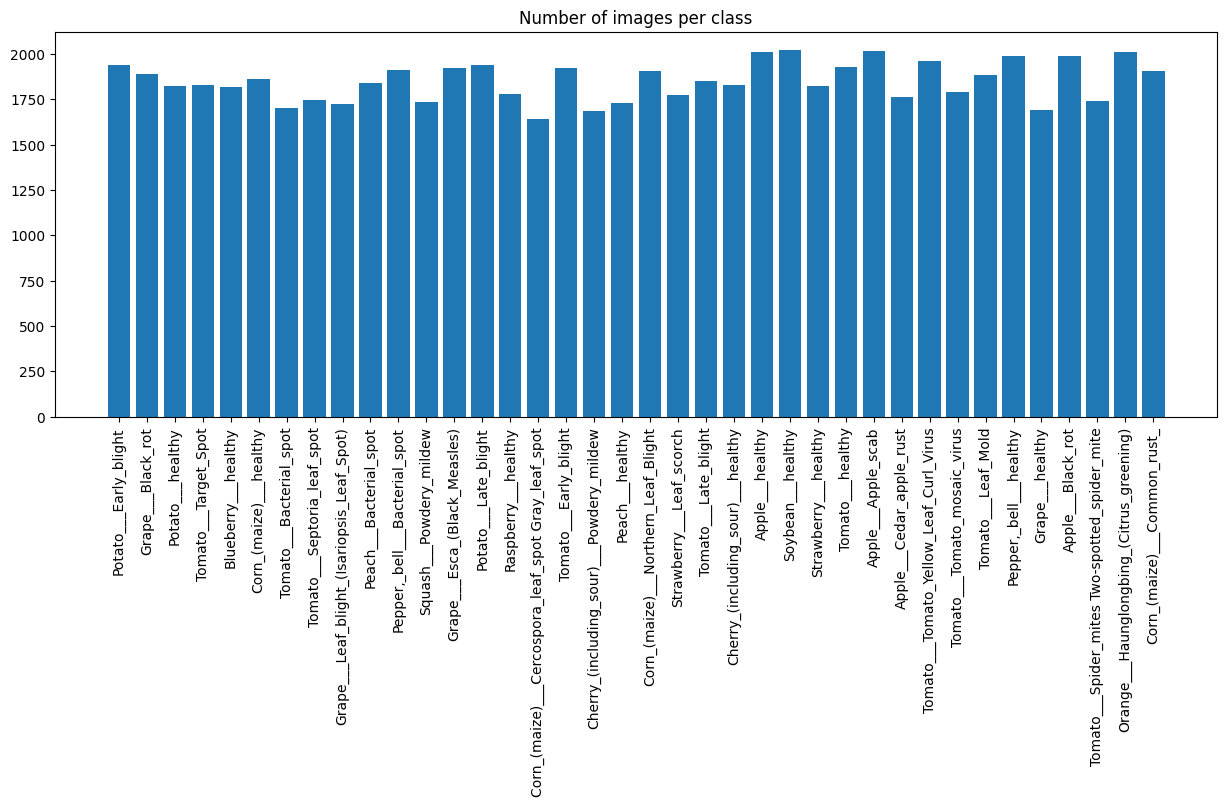

In [ ]:
plt.figure(figsize=(15,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.title("Number of images per class")
plt.show()

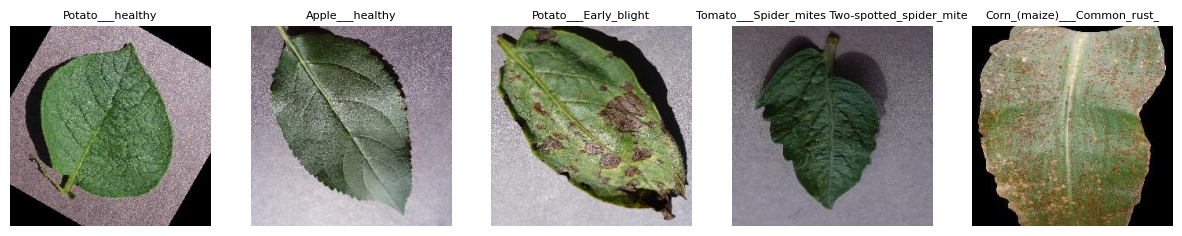

In [ ]:
import random

sample_classes = random.sample(list(class_counts.keys()), 5)

plt.figure(figsize=(15,3))
for i, cls in enumerate(sample_classes):
    img_name = os.listdir(os.path.join(train_dir, cls))[0]
    img = cv2.imread(os.path.join(train_dir, cls, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title(cls, fontsize=8)
    plt.axis("off")
plt.show()

In [ ]:
sample_img = cv2.imread(os.path.join(train_dir, sample_classes[0], os.listdir(os.path.join(train_dir, sample_classes[0]))[0]))
print("Sample image shape:", sample_img.shape)

Sample image shape: (256, 256, 3)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

num_classes = len(class_counts)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_size, img_size, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),          # prevents overfitting
    Dense(num_classes, activation='softmax')   # one output per disease class
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,309,542 (12.62 MB)

 Trainable params: 3,309,542 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=20, zoom_range=0.2, horizontal_flip=True)
valid_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(train_dir, target_size=(img_size, img_size), batch_size=batch_size, class_mode="categorical")
valid_data = valid_datagen.flow_from_directory(valid_dir, target_size=(img_size, img_size), batch_size=batch_size, class_mode="categorical")

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [ ]:
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2853s 1s/step - accuracy: 0.4411 - loss: 1.9272 - val_accuracy: 0.7069 - val_loss: 0.9701
Epoch 2/10


In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=20, zoom_range=0.2, horizontal_flip=True)
valid_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir, target_size=(img_size, img_size), batch_size=batch_size, class_mode="categorical"
)
valid_data = valid_datagen.flow_from_directory(
    valid_dir, target_size=(img_size, img_size), batch_size=batch_size, class_mode="categorical"
)

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

In [ ]:
loss, accuracy = model.evaluate(valid_data)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

In [ ]:
model.save("plant_disease_cnn.h5")

In [ ]:
class_names = list(train_data.class_indices.keys())

print(class_names)

In [ ]:
from tensorflow.keras.utils import load_img, img_to_array

image_path = "your_image.jpg"

img = load_img(
    image_path,
    target_size=(img_size, img_size)
)

img_array = img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = np.argmax(prediction[0])

print("Predicted disease:", class_names[predicted_class])
print("Confidence:", prediction[0][predicted_class] * 100)

In [ ]:
plt.figure(figsize=(5, 5))

plt.imshow(img)
plt.axis("off")

plt.title(
    f"Prediction: {class_names[predicted_class]}\n"
    f"Confidence: {prediction[0][predicted_class] * 100:.2f}%"
)

plt.show()

In [ ]:

import json

# Save the trained model so it can be plugged into the Streamlit app
os.makedirs("model", exist_ok=True)
model.save("model/plant_disease_model.h5")

# Optional: save training history so the Insights tab can plot the accuracy curve
with open("model/history.json", "w") as f:
    json.dump(history.history, f)

print("Saved model/plant_disease_model.h5 and model/history.json")